In [27]:
import time

import numpy as np
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import functional as F

from common import G2OpGymEnv, BusConnectivityGraphObsSpace
from nri import Encoder, GumbelSoftmax
from nri import prior_from_env
from nri.agent.graphormer.GraphormerEncoder import GraphormerNRIEncoder
from nri.agent.pretrain_encoder import create_dataset, GraphDataset
from nri.agent.pretrain_encoder import train
from visualization import PlottingArgs, visualize_graph
from visualization import get_node_styles

In [28]:
def get_env():
    return G2OpGymEnv(
        obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space, normalization_boundaries={
            "active_power_forecast": [-122.4, 116.666],
            "active_power": [-122.4, 116.666],
            "reactive_power_forecast": [-85.7, 107.228],
            "reactive_power": [-85.7, 107.228],
            "voltage": [-142.1, 142.1],
            "voltage_angle": [-14.212, 1.246],
            "current": [0, 1512],
            "rho": [0, 1]
        }))


eps = 0.0000001
prior_for_graph_edges = 0.9
ds_size = 1000

# create prior and dataset
env = get_env()
prior = prior_from_env(prior_for_graph_edges, env)
ds: GraphDataset = create_dataset(env, prior, ds_size)
ds_test: GraphDataset = create_dataset(get_env(), prior, ds_size)

2025-11-21 17:40:45,296 - common.constants - INFO - Using graph observation space with 57 nodes, ≤ 244 edges and 8 features per node (active_power_forecast, reactive_power_forecast, active_power, reactive_power, voltage, voltage_angle, current, rho).
2025-11-21 17:40:45,307 - common.constants - INFO - Prior for graph edges: tensor([0.9000, 0.1000]), Prior for non graph edges: tensor([0.0541, 0.9459])


Create dataset:   0%|          | 0/1000 [00:00<?, ?it/s]

Create dataset:   0%|          | 1/1000 [00:00<07:50,  2.12it/s]

Create dataset:   7%|▋         | 67/1000 [00:00<00:06, 154.98it/s]

Create dataset:  14%|█▎        | 135/1000 [00:00<00:03, 284.74it/s]

Create dataset:  20%|██        | 203/1000 [00:00<00:02, 387.08it/s]

Create dataset:  27%|██▋       | 270/1000 [00:00<00:01, 463.58it/s]

Create dataset:  34%|███▍      | 338/1000 [00:00<00:01, 522.51it/s]

Create dataset:  40%|████      | 402/1000 [00:01<00:01, 555.55it/s]

Create dataset:  47%|████▋     | 469/1000 [00:01<00:00, 5

In [29]:
graphormer_encoder = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=1, num_edge_types=2, max_degree=7, max_path_distance=9)
nri_encoder = Encoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, dropout_prob=0.0)

results = {
    "Graphormer": {"loss": [], "time": -1},
    "NRI":  {"loss": [], "time": -1},
}

encoders = {
    "Graphormer": graphormer_encoder,
    "NRI": nri_encoder
}

for name, encoder in encoders.items():
    start = time.time()
    results[name]["loss"] = train(encoder, ds, num_epochs=2, evaluate_every_k_epochs=50)
    results[name]["time"] = (time.time() - start)




  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:01<00:01,  1.19s/it]

Epoch 1, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00: 100%|██████████| 2/2 [00:02<00:00,  1.24s/it]


  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:08<00:08,  8.53s/it]

Epoch 1, Loss: 0.00188297, Max Grads: 0.02, logits max: 4.52: 100%|██████████| 2/2 [00:16<00:00,  8.43s/it]


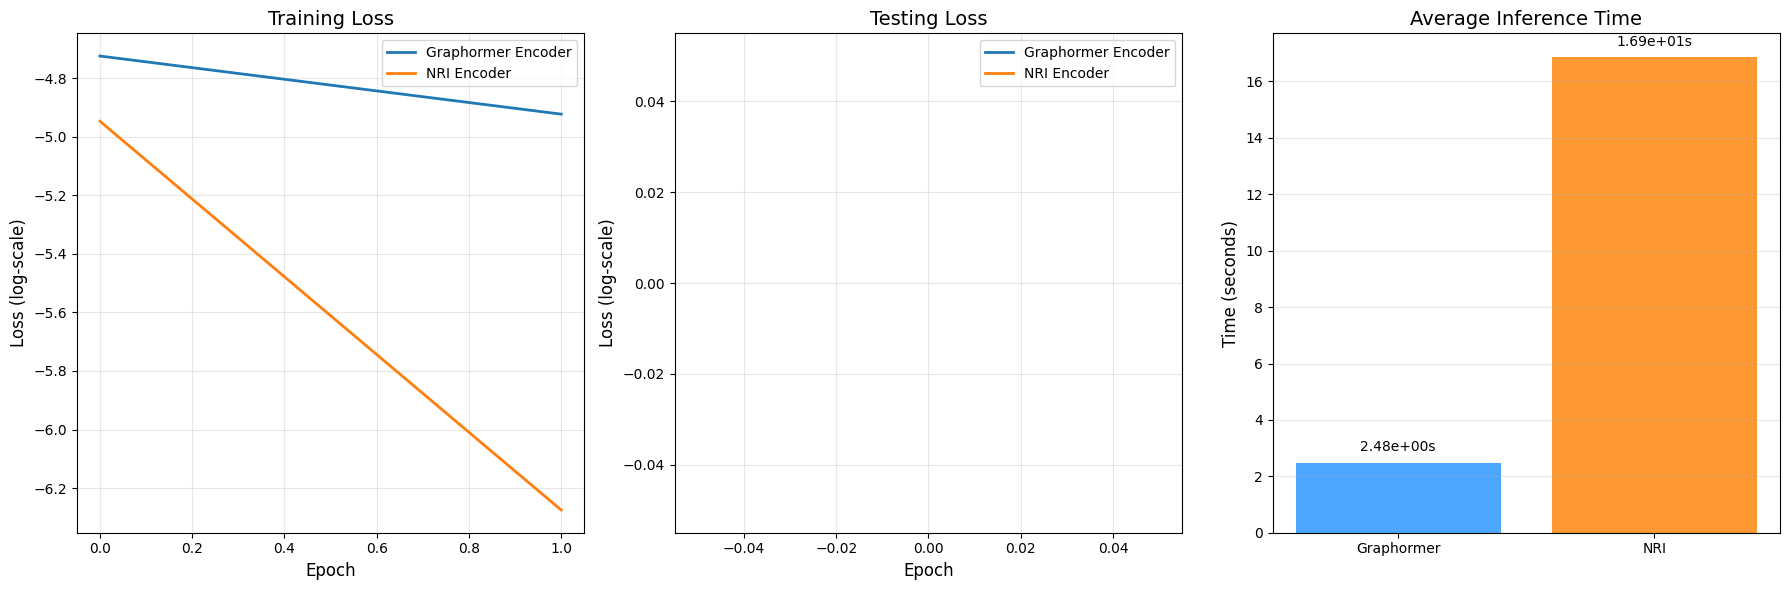

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ----- Loss Plot -----
graphormer_train_loss = np.log(np.array([train for train, _ in results["Graphormer"]["loss"]]) + eps)
nri_train_loss = np.log(np.array([train for train, _ in results["NRI"]["loss"]]) + eps)
axes[0].plot(graphormer_train_loss, label="Graphormer Encoder", linewidth=2)
axes[0].plot(nri_train_loss, label="NRI Encoder", linewidth=2)

axes[0].set_title("Training Loss", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (log-scale)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----- Testing Loss Plot -----
graphormer_test_loss = np.log(np.array([test for _, test in results["Graphormer"]["loss"]], dtype=np.float32) + eps)
nri_test_loss = np.log(np.array([test for _, test in results["NRI"]["loss"]], dtype=np.float32) + eps)
x = np.arange(len(graphormer_test_loss))
graphormer_mask = ~np.isnan(graphormer_test_loss)
nri_mask = ~np.isnan(nri_test_loss)

axes[1].plot(x[graphormer_mask], graphormer_test_loss[graphormer_mask], label="Graphormer Encoder", linewidth=2)
axes[1].plot(x[nri_mask], nri_test_loss[nri_mask], label="NRI Encoder", linewidth=2)

axes[1].set_title("Testing Loss", fontsize=14)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Loss (log-scale)", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# ----- Inference Time Bar Chart -----
methods = ["Graphormer", "NRI"]
values = [results["Graphormer"]["time"], results["NRI"]["time"]]

bars = axes[2].bar(methods, values, color=["#4da6ff", "#ff9933"])

# Add exact value labels above bars
for bar, val in zip(bars, values):
    axes[2].annotate(f"{val:.2e}s",
                     xy=(bar.get_x() + bar.get_width() / 2, val),
                     xytext=(0, 6),
                     textcoords="offset points",
                     ha="center", va="bottom",
                     fontsize=10)

axes[2].set_title("Average Inference Time", fontsize=14)
axes[2].set_ylabel("Time (seconds)", fontsize=12)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Graphormer encoder is able to approximate the prior equally well as the NRI Encoder. Since it has a more general understanding of the structure of the powergrid, it is likely better suited to make predictions for latent graph structures. Additionally, inference in the GT module is ~x9 faster.

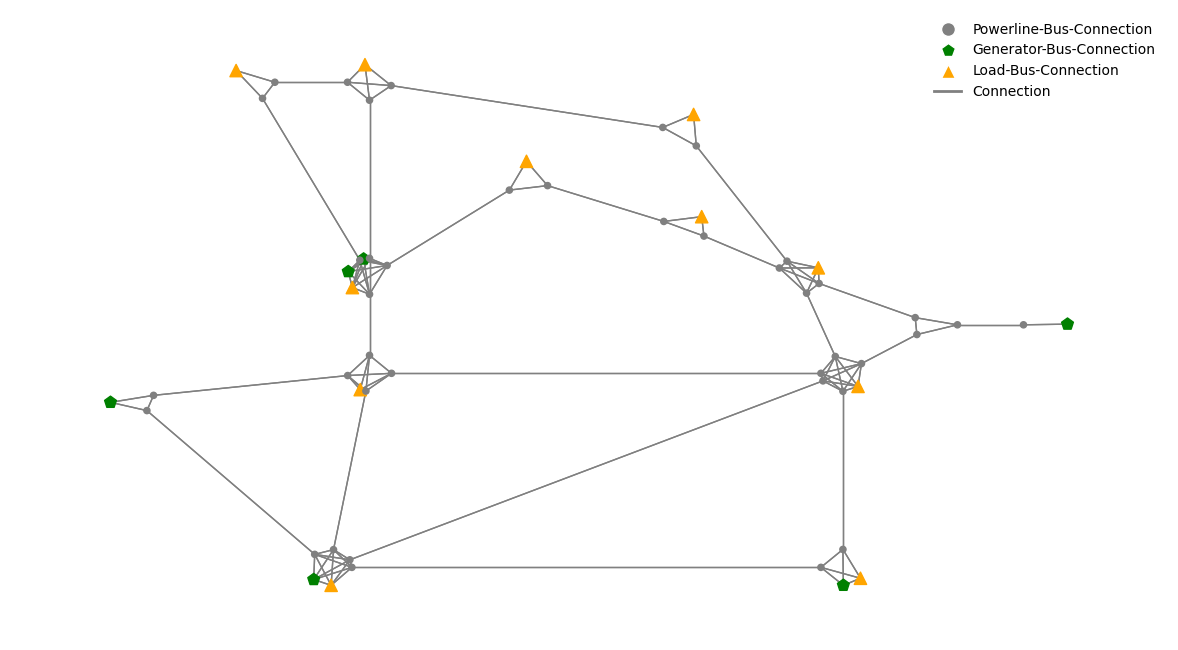

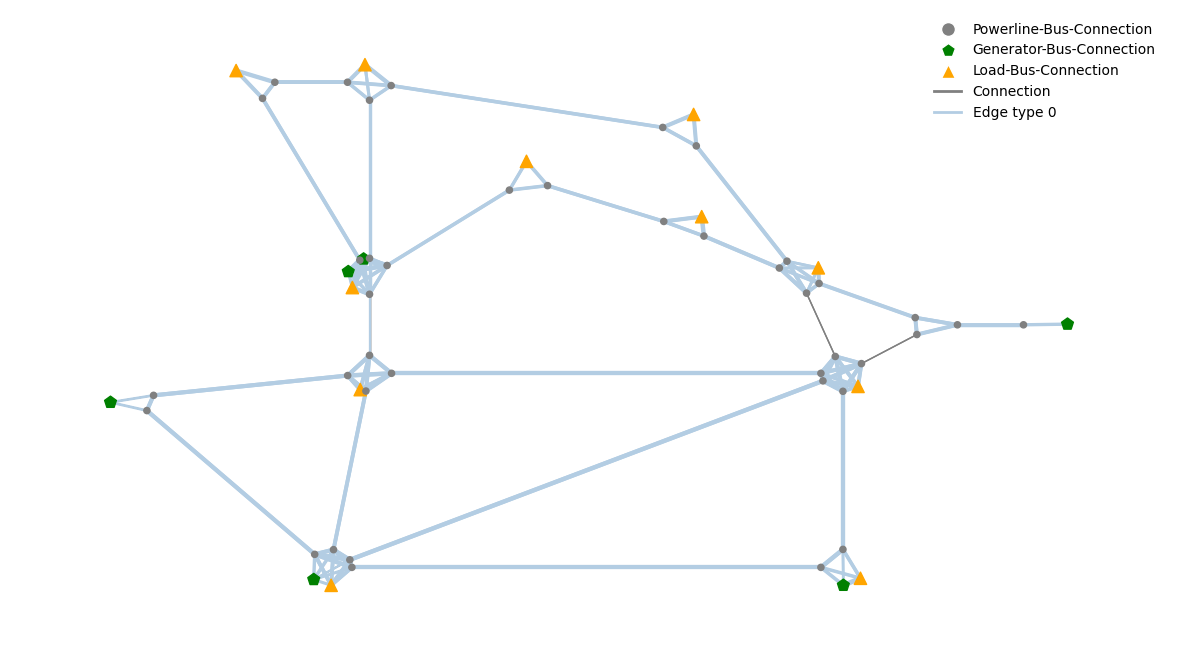

In [31]:
sample = ds_test.get(0)
gumbel = GumbelSoftmax()

x = sample.x
powerline_edge_index = sample.edge_index

for enc in [graphormer_encoder, nri_encoder]:
    encoder_logits: Tensor = enc.forward(x=x, powerline_edge_index=powerline_edge_index) # [E, K]
    p_z_given_x: Tensor = F.softmax(encoder_logits, dim=-1).detach().cpu().numpy() # [E, K]
    p_one_hot: Tensor = gumbel.forward(x=encoder_logits).detach().cpu().numpy() # [E, K]

    plotting_args = PlottingArgs(
        env.observation_space.num_nodes,
        get_node_styles(env._g2op_env, env.observation_space.__class__),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=p_z_given_x,
    )
    visualize_graph(plotting_args)

In [ ]:
loss_curves_per_run = []
n_runs = 10
for i in range(n_runs):
    graphormer_encoder_short = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=1, num_edge_types=2, max_degree=7, max_path_distance=9)
    loss_curve = train(graphormer_encoder_short, ds, num_epochs=50)
    loss_curves_per_run.append(loss_curve)



Epoch 22, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  46%|████▌     | 23/50 [24:51<29:11, 64.86s/it]


  2%|▏         | 1/50 [00:01<01:06,  1.36s/it]

Epoch 0, Loss: 0.00904893, Max Grads: 0.00, logits max: 0.00:   4%|▍         | 2/50 [00:02<01:03,  1.33s/it]

Epoch 1, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:   6%|▌         | 3/50 [00:04<01:04,  1.37s/it]

Epoch 2, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:   8%|▊         | 4/50 [00:05<01:08,  1.50s/it]

Epoch 3, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  10%|█         | 5/50 [00:06<01:02,  1.39s/it]

Epoch 4, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  12%|█▏        | 6/50 [00:08<00:57,  1.31s/it]

Epoch 5, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  14%|█▍        | 7/50 [00:09<00:54,  1.26s/it]

Epoch 6, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  16%|█▌        | 8/50 [00:10<00:51,  1.22s/it]

Epoch 7, Loss: 0.00727720, Max Grads: 0.00, logits max: 0.00:  18%|

In [ ]:
loss_arr = np.log(np.array(loss_curves_per_run) + eps)
mean_loss = loss_arr.mean(axis=0)
std_loss = loss_arr.std(axis=0)
epochs = np.arange(loss_arr.shape[1])

plt.figure(figsize=(6,4))
plt.plot(epochs, mean_loss, label="Mean loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3)
for i, run in enumerate(loss_arr):
    plt.plot(epochs, run, label=f"Run {i}", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()